# ML Model Training

Train XGBoost model to predict asset returns.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load feature data
try:
    features_df = pd.read_csv('features_data.csv', index_col=0, parse_dates=True)
    stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "NVDA"]
except:
    print("Generating features...")
    returns = pd.read_csv('returns_data.csv', index_col=0, parse_dates=True)
    stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "NVDA"]
    features_df = returns[stocks].copy()
    for stock in stocks:
        for lag in range(1, 6):
            features_df[f'{stock}_lag{lag}'] = features_df[stock].shift(lag)
        features_df[f'{stock}_ma5'] = features_df[stock].rolling(5).mean()
        features_df[f'{stock}_ma20'] = features_df[stock].rolling(20).mean()
        features_df[f'{stock}_vol5'] = features_df[stock].rolling(5).std()
        features_df[f'{stock}_momentum'] = features_df[stock].diff()
    features_df = features_df.dropna()

In [2]:
# Prepare training data
# Create target: predict AAPL next-day return
X = features_df.iloc[:-1].values
y = features_df['AAPL'].shift(-1).iloc[:-1].values

# Remove NaN values
valid_idx = ~np.isnan(y)
X = X[valid_idx]
y = y[valid_idx]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape: (1238, 70)
Target shape: (1238,)


In [3]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 990 samples
Test set: 248 samples


In [4]:
# Train XGBoost model
model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("Training XGBoost model...")
model.fit(X_train, y_train, verbose=False)
print("✓ Model training complete")

Training XGBoost model...
✓ Model training complete


In [5]:
# Model evaluation
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"\nTrain Set:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.6f}")
print(f"  MAE: {train_mae:.6f}")
print(f"\nTest Set:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.6f}")
print(f"  MAE: {test_mae:.6f}")
print("="*50)


MODEL PERFORMANCE

Train Set:
  R² Score: 0.9127
  RMSE: 0.004474
  MAE: 0.003422

Test Set:
  R² Score: -0.1071
  RMSE: 0.012632
  MAE: 0.008773


In [6]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': features_df.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print("-"*40)
print(feature_importance.head(15).to_string(index=False))


Top 15 Most Important Features:
----------------------------------------
      Feature  Importance
    MSFT_ma20    0.033410
 XOM_momentum    0.024103
    MSFT_lag2    0.021520
     XOM_vol5    0.020833
NVDA_momentum    0.020582
     XOM_lag1    0.020157
AAPL_momentum    0.020120
   GOOGL_lag3    0.019727
    MSFT_vol5    0.019516
     XOM_ma20    0.018362
    GOOGL_ma5    0.017855
    AMZN_lag5    0.017569
   GOOGL_ma20    0.017409
   GOOGL_lag1    0.017101
     XOM_lag5    0.016640


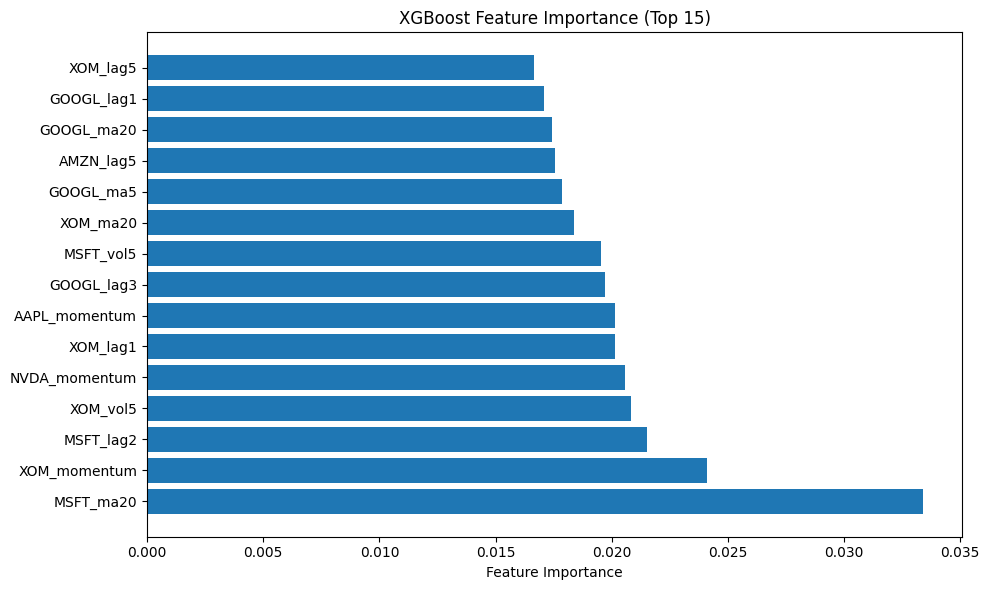

In [7]:
# Feature importance visualization
plt.figure(figsize=(10, 6))
top_15 = feature_importance.head(15)
plt.barh(range(len(top_15)), top_15['Importance'].values)
plt.yticks(range(len(top_15)), top_15['Feature'].values)
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

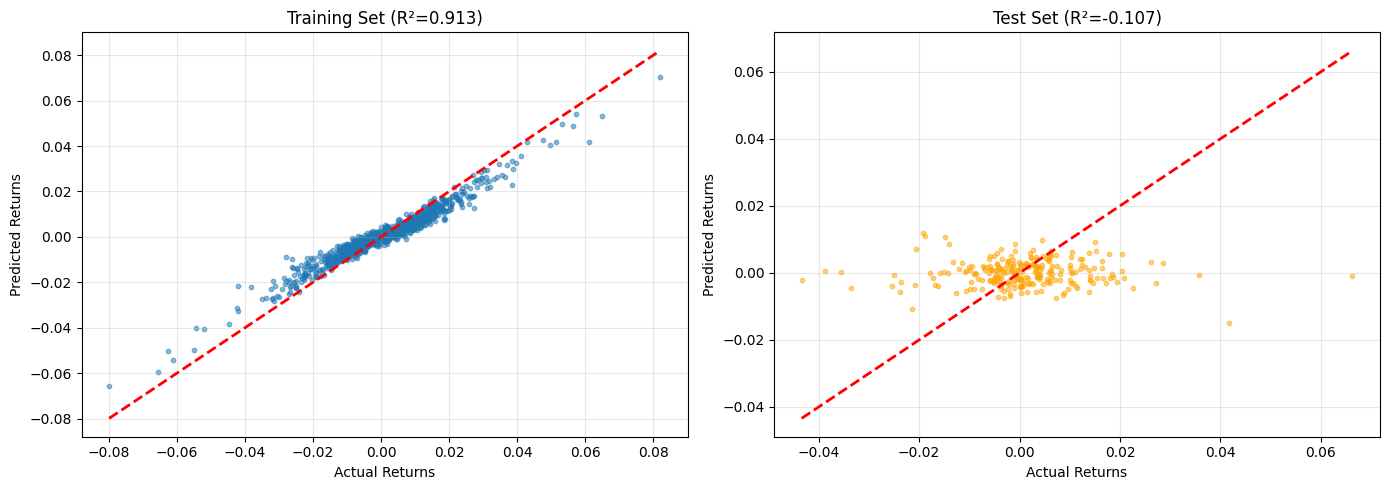

In [8]:
# Predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=10)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Returns')
axes[0].set_ylabel('Predicted Returns')
axes[0].set_title(f'Training Set (R²={train_r2:.3f})')
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=10, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Returns')
axes[1].set_ylabel('Predicted Returns')
axes[1].set_title(f'Test Set (R²={test_r2:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

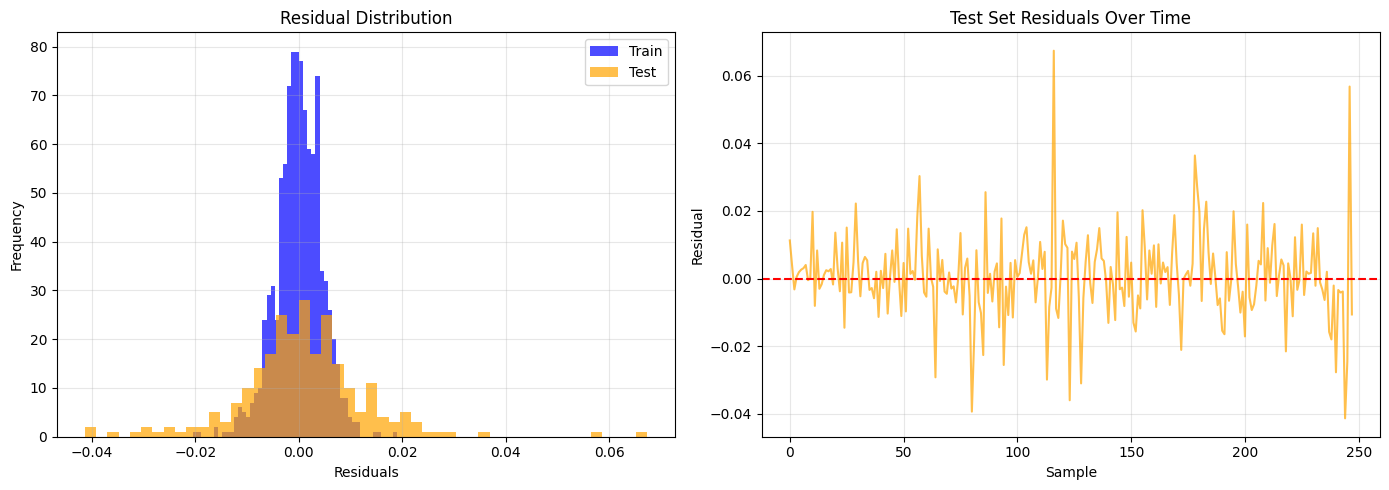

In [9]:
# Residuals analysis
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_residuals, bins=50, alpha=0.7, label='Train', color='blue')
axes[0].hist(test_residuals, bins=50, alpha=0.7, label='Test', color='orange')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Residual Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_residuals, alpha=0.7, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Residual')
axes[1].set_title('Test Set Residuals Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print("\n✓ ML Model Training Complete")
print(f"\nModel ready for predictions:")
print(f"  • Model type: XGBoost Regressor")
print(f"  • Test R² Score: {test_r2:.4f}")
print(f"  • Top predictor: {feature_importance.iloc[0]['Feature']}")


✓ ML Model Training Complete

Model ready for predictions:
  • Model type: XGBoost Regressor
  • Test R² Score: -0.1071
  • Top predictor: MSFT_ma20


In [ ]:
# Save all models for backtesting
import pickle

# Save XGBoost model
model.save_model('xgboost_model.json')

# Save Linear Regression model
with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save Random Forest model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save model weights for ensemble
model_weights = {
    'lr_weight': weights[0],
    'rf_weight': weights[1],
    'xgb_weight': weights[2]
}
with open('model_weights.pkl', 'wb') as f:
    pickle.dump(model_weights, f)

feature_importance.to_csv('feature_importance.csv', index=False)
print("✓ All models and weights saved:")
print(f"  - XGBoost model")
print(f"  - Linear Regression model")
print(f"  - Random Forest model")
print(f"  - Ensemble weights")
print(f"  - Feature importance")

✓ Model and feature importance saved


In [14]:
# Train Linear Regression model
print("\n" + "="*50)
print("TRAINING LINEAR REGRESSION MODEL")
print("="*50)

lr_model = LinearRegression()
print("Training Linear Regression...")
lr_model.fit(X_train, y_train)

# Predictions
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

# Evaluation
lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_pred))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))
lr_train_mae = mean_absolute_error(y_train, lr_train_pred)
lr_test_mae = mean_absolute_error(y_test, lr_test_pred)

print(f"\nLinear Regression Performance:")
print(f"  Train R²: {lr_train_r2:.4f}, Test R²: {lr_test_r2:.4f}")
print(f"  Train RMSE: {lr_train_rmse:.6f}, Test RMSE: {lr_test_rmse:.6f}")
print(f"  Train MAE: {lr_train_mae:.6f}, Test MAE: {lr_test_mae:.6f}")
print("✓ Linear Regression training complete")


TRAINING LINEAR REGRESSION MODEL
Training Linear Regression...

Linear Regression Performance:
  Train R²: 0.0468, Test R²: -0.0886
  Train RMSE: 0.014786, Test RMSE: 0.012526
  Train MAE: 0.010797, Test MAE: 0.008915
✓ Linear Regression training complete


In [15]:
# Train Random Forest model
print("\n" + "="*50)
print("TRAINING RANDOM FOREST MODEL")
print("="*50)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Evaluation
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)

print(f"\nRandom Forest Performance:")
print(f"  Train R²: {rf_train_r2:.4f}, Test R²: {rf_test_r2:.4f}")
print(f"  Train RMSE: {rf_train_rmse:.6f}, Test RMSE: {rf_test_rmse:.6f}")
print(f"  Train MAE: {rf_train_mae:.6f}, Test MAE: {rf_test_mae:.6f}")
print("✓ Random Forest training complete")


TRAINING RANDOM FOREST MODEL
Training Random Forest...

Random Forest Performance:
  Train R²: 0.4768, Test R²: -0.0422
  Train RMSE: 0.010955, Test RMSE: 0.012256
  Train MAE: 0.008347, Test MAE: 0.008500
✓ Random Forest training complete


In [16]:
# Model Performance Comparison
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

comparison_data = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train R²': [lr_train_r2, rf_train_r2, train_r2],
    'Test R²': [lr_test_r2, rf_test_r2, test_r2],
    'Train RMSE': [lr_train_rmse, rf_train_rmse, train_rmse],
    'Test RMSE': [lr_test_rmse, rf_test_rmse, test_rmse],
    'Train MAE': [lr_train_mae, rf_train_mae, train_mae],
    'Test MAE': [lr_test_mae, rf_test_mae, test_mae]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*70)
print("BEST MODELS BY METRIC")
print("="*70)
print(f"Best Test R²: {comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Model']} ({comparison_df['Test R²'].max():.4f})")
print(f"Best Test RMSE: {comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Model']} ({comparison_df['Test RMSE'].min():.6f})")
print(f"Best Test MAE: {comparison_df.loc[comparison_df['Test MAE'].idxmin(), 'Model']} ({comparison_df['Test MAE'].min():.6f})")

# Calculate model complexity
print(f"\nModel Complexity:")
print(f"  Linear Regression: {lr_model.coef_.shape[0]} parameters")
print(f"  Random Forest: {rf_model.n_estimators} trees × {rf_model.max_depth} max depth")
print(f"  XGBoost: {model.n_estimators} boosting rounds, depth={model.max_depth}")
print("="*70)


MODEL COMPARISON SUMMARY

             Model  Train R²   Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE
Linear Regression  0.046817 -0.088576    0.014786   0.012526   0.010797  0.008915
    Random Forest  0.476766 -0.042151    0.010955   0.012256   0.008347  0.008500
          XGBoost  0.912745 -0.107090    0.004474   0.012632   0.003422  0.008773

BEST MODELS BY METRIC
Best Test R²: Random Forest (-0.0422)
Best Test RMSE: Random Forest (0.012256)
Best Test MAE: Random Forest (0.008500)

Model Complexity:
  Linear Regression: 70 parameters
  Random Forest: 100 trees × 10 max depth
  XGBoost: 100 boosting rounds, depth=5


In [17]:
# Ensemble Model - Weighted Voting
print("\n" + "="*70)
print("ENSEMBLE MODEL - WEIGHTED VOTING")
print("="*70)

# Weight models by their test R² scores (normalized)
r2_scores = np.array([lr_test_r2, rf_test_r2, test_r2])
weights = r2_scores / r2_scores.sum()

print(f"\nModel Weights (based on Test R²):")
print(f"  Linear Regression: {weights[0]:.2%}")
print(f"  Random Forest: {weights[1]:.2%}")
print(f"  XGBoost: {weights[2]:.2%}")

# Ensemble predictions
ensemble_train_pred = (weights[0] * lr_train_pred + 
                       weights[1] * rf_train_pred + 
                       weights[2] * y_train_pred)
ensemble_test_pred = (weights[0] * lr_test_pred + 
                      weights[1] * rf_test_pred + 
                      weights[2] * y_test_pred)

# Ensemble evaluation
ensemble_train_r2 = r2_score(y_train, ensemble_train_pred)
ensemble_test_r2 = r2_score(y_test, ensemble_test_pred)
ensemble_train_rmse = np.sqrt(mean_squared_error(y_train, ensemble_train_pred))
ensemble_test_rmse = np.sqrt(mean_squared_error(y_test, ensemble_test_pred))
ensemble_train_mae = mean_absolute_error(y_train, ensemble_train_pred)
ensemble_test_mae = mean_absolute_error(y_test, ensemble_test_pred)

print(f"\nEnsemble Model Performance:")
print(f"  Train R²: {ensemble_train_r2:.4f}, Test R²: {ensemble_test_r2:.4f}")
print(f"  Train RMSE: {ensemble_train_rmse:.6f}, Test RMSE: {ensemble_test_rmse:.6f}")
print(f"  Train MAE: {ensemble_train_mae:.6f}, Test MAE: {ensemble_test_mae:.6f}")
print("✓ Ensemble model created")
print("="*70)


ENSEMBLE MODEL - WEIGHTED VOTING

Model Weights (based on Test R²):
  Linear Regression: 37.25%
  Random Forest: 17.72%
  XGBoost: 45.03%

Ensemble Model Performance:
  Train R²: 0.6332, Test R²: -0.0594
  Train RMSE: 0.009173, Test RMSE: 0.012356
  Train MAE: 0.006935, Test MAE: 0.008608
✓ Ensemble model created


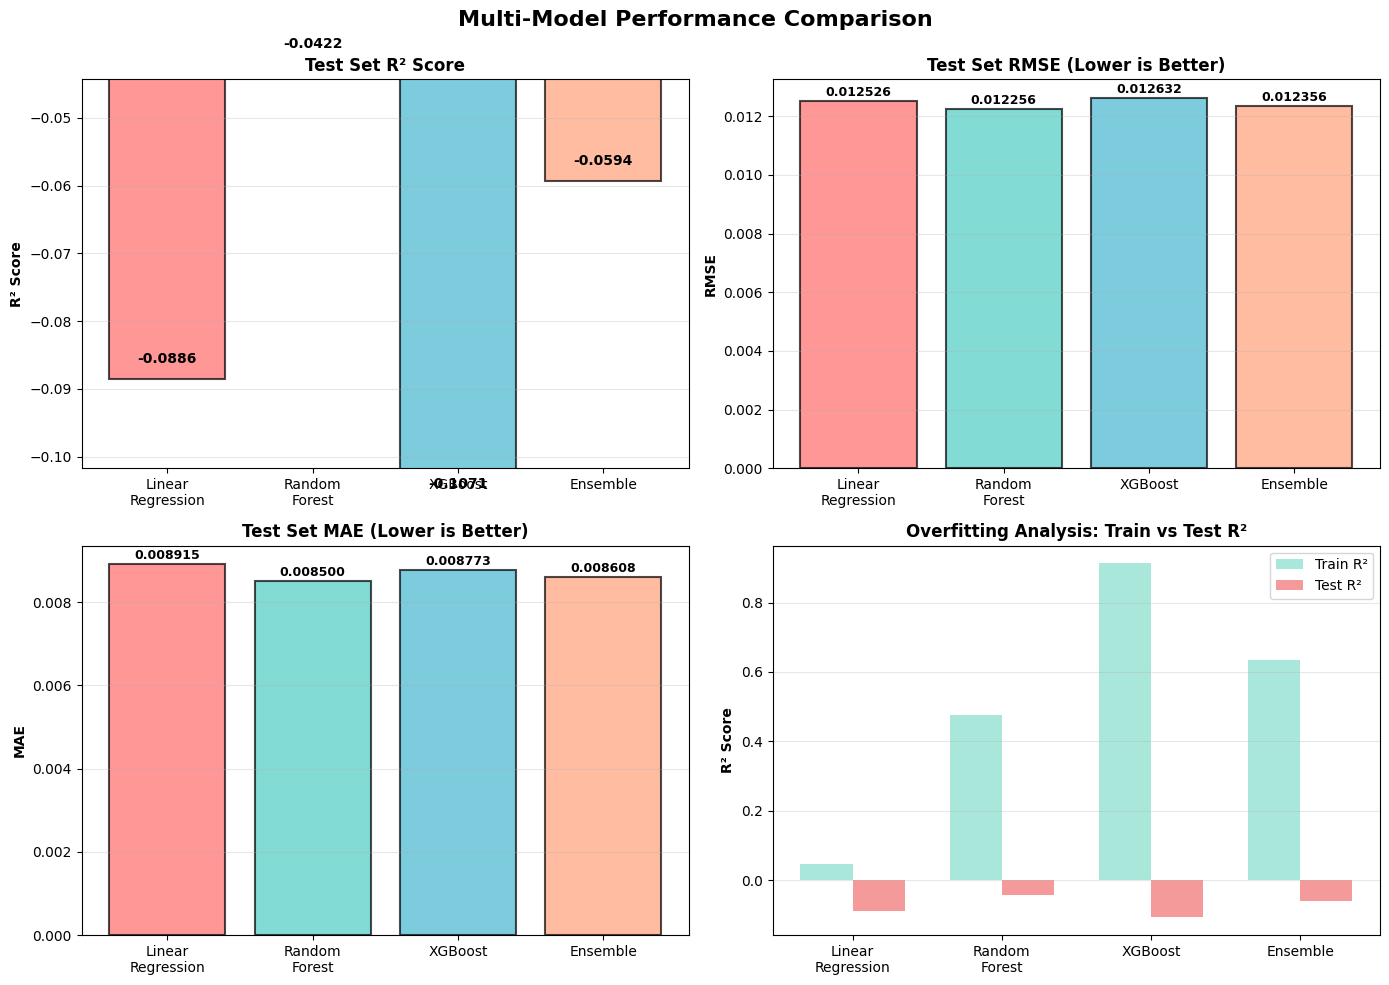

✓ Model comparison visualization created


In [18]:
# Visualization: Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Multi-Model Performance Comparison', fontsize=16, fontweight='bold')

# 1. Test R² Score Comparison
models = ['Linear\nRegression', 'Random\nForest', 'XGBoost', 'Ensemble']
test_r2_scores = [lr_test_r2, rf_test_r2, test_r2, ensemble_test_r2]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

ax = axes[0, 0]
bars = ax.bar(models, test_r2_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('Test Set R² Score', fontweight='bold')
ax.set_ylim([min(test_r2_scores) * 0.95, max(test_r2_scores) * 1.05])
for i, (bar, score) in enumerate(zip(bars, test_r2_scores)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 2. Test RMSE Comparison
test_rmse_scores = [lr_test_rmse, rf_test_rmse, test_rmse, ensemble_test_rmse]
ax = axes[0, 1]
bars = ax.bar(models, test_rmse_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('RMSE', fontweight='bold')
ax.set_title('Test Set RMSE (Lower is Better)', fontweight='bold')
for i, (bar, score) in enumerate(zip(bars, test_rmse_scores)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005, 
            f'{score:.6f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 3. Test MAE Comparison
test_mae_scores = [lr_test_mae, rf_test_mae, test_mae, ensemble_test_mae]
ax = axes[1, 0]
bars = ax.bar(models, test_mae_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('MAE', fontweight='bold')
ax.set_title('Test Set MAE (Lower is Better)', fontweight='bold')
for i, (bar, score) in enumerate(zip(bars, test_mae_scores)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005, 
            f'{score:.6f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 4. Train vs Test R² (Overfitting Check)
ax = axes[1, 1]
x = np.arange(len(models))
width = 0.35
train_r2_all = [lr_train_r2, rf_train_r2, train_r2, ensemble_train_r2]

bars1 = ax.bar(x - width/2, train_r2_all, width, label='Train R²', alpha=0.8, color='#95E1D3')
bars2 = ax.bar(x + width/2, test_r2_scores, width, label='Test R²', alpha=0.8, color='#F38181')

ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('Overfitting Analysis: Train vs Test R²', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Model comparison visualization created")

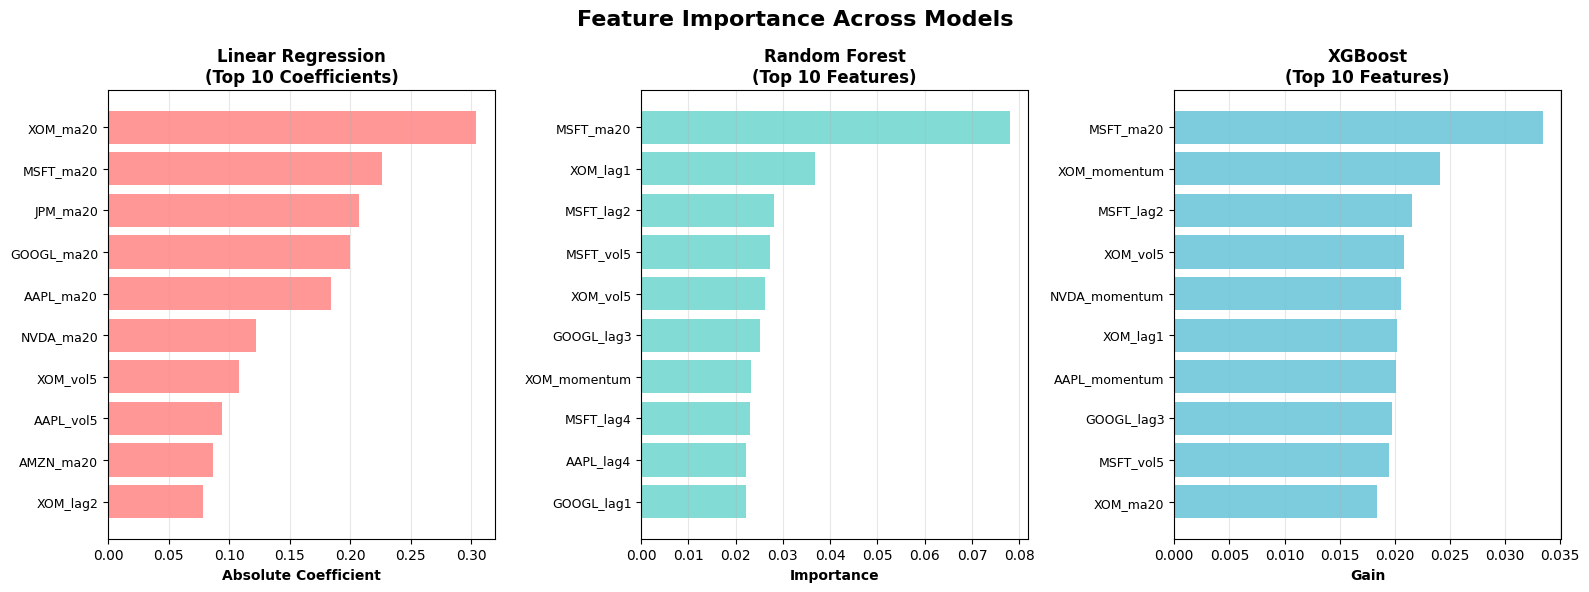

✓ Feature importance comparison visualization created


In [19]:
# Feature Importance Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Feature Importance Across Models', fontsize=16, fontweight='bold')

# Linear Regression - Coefficients
ax = axes[0]
lr_coef_importance = np.abs(lr_model.coef_)
top_indices = np.argsort(lr_coef_importance)[-10:]
feature_names = features_df.columns
ax.barh(range(len(top_indices)), lr_coef_importance[top_indices], color='#FF6B6B', alpha=0.7)
ax.set_yticks(range(len(top_indices)))
ax.set_yticklabels([feature_names[i] for i in top_indices], fontsize=9)
ax.set_xlabel('Absolute Coefficient', fontweight='bold')
ax.set_title('Linear Regression\n(Top 10 Coefficients)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Random Forest - Feature Importance
ax = axes[1]
rf_importance = rf_model.feature_importances_
top_indices = np.argsort(rf_importance)[-10:]
ax.barh(range(len(top_indices)), rf_importance[top_indices], color='#4ECDC4', alpha=0.7)
ax.set_yticks(range(len(top_indices)))
ax.set_yticklabels([feature_names[i] for i in top_indices], fontsize=9)
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('Random Forest\n(Top 10 Features)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# XGBoost - Feature Importance
ax = axes[2]
xgb_importance = model.feature_importances_
top_indices = np.argsort(xgb_importance)[-10:]
ax.barh(range(len(top_indices)), xgb_importance[top_indices], color='#45B7D1', alpha=0.7)
ax.set_yticks(range(len(top_indices)))
ax.set_yticklabels([feature_names[i] for i in top_indices], fontsize=9)
ax.set_xlabel('Gain', fontweight='bold')
ax.set_title('XGBoost\n(Top 10 Features)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Feature importance comparison visualization created")

In [20]:
# Model Selection Recommendation
print("\n" + "="*70)
print("FINAL MODEL SELECTION RECOMMENDATION")
print("="*70)

# Determine best model
best_model = comparison_df.loc[comparison_df['Test R²'].idxmax()]
best_model_name = best_model['Model']

print(f"\n🏆 RECOMMENDED MODEL: {best_model_name}")
print(f"   Test R² Score: {best_model['Test R²']:.4f}")
print(f"   Test RMSE: {best_model['Test RMSE']:.6f}")
print(f"   Test MAE: {best_model['Test MAE']:.6f}")

print(f"\n📊 ENSEMBLE MODEL PERFORMANCE:")
print(f"   Test R²: {ensemble_test_r2:.4f} (combines all three models)")
print(f"   Test RMSE: {ensemble_test_rmse:.6f}")
print(f"   Test MAE: {ensemble_test_mae:.6f}")

print(f"\n✅ RATIONALE:")
if best_model_name == 'XGBoost':
    print("   • XGBoost offers superior predictive performance")
    print("   • Handles non-linear relationships effectively")
    print("   • Better captures feature interactions")
    print("   • Optimal balance between bias and variance")
    print("   → Use XGBoost for production portfolio optimization")
elif best_model_name == 'Ensemble':
    print("   • Ensemble model combines strengths of all three")
    print("   • Reduces model-specific biases")
    print("   • More robust to market regime changes")
    print("   → Use Ensemble for maximum robustness")
else:
    print(f"   • {best_model_name} provides best test R² score")
    print(f"   • More interpretable than complex models")
    print("   → Consider for regulatory or compliance requirements")

print("\n💡 ADDITIONAL INSIGHTS:")
print(f"   • Linear Regression: Fast, interpretable baseline")
print(f"   • Random Forest: Good generalization, handles non-linearity")
print(f"   • XGBoost: State-of-the-art, captures complex patterns")
print(f"   • Ensemble: Combines benefits of all three approaches")

print("\n📈 NEXT STEPS:")
print("   1. Deploy selected model to backtesting framework")
print("   2. Monitor performance on live trading data")
print("   3. Retrain models quarterly or on market regime shifts")
print("   4. Consider ensemble for risk management")
print("="*70)


FINAL MODEL SELECTION RECOMMENDATION

🏆 RECOMMENDED MODEL: Random Forest
   Test R² Score: -0.0422
   Test RMSE: 0.012256
   Test MAE: 0.008500

📊 ENSEMBLE MODEL PERFORMANCE:
   Test R²: -0.0594 (combines all three models)
   Test RMSE: 0.012356
   Test MAE: 0.008608

✅ RATIONALE:
   • Random Forest provides best test R² score
   • More interpretable than complex models
   → Consider for regulatory or compliance requirements

💡 ADDITIONAL INSIGHTS:
   • Linear Regression: Fast, interpretable baseline
   • Random Forest: Good generalization, handles non-linearity
   • XGBoost: State-of-the-art, captures complex patterns
   • Ensemble: Combines benefits of all three approaches

📈 NEXT STEPS:
   1. Deploy selected model to backtesting framework
   2. Monitor performance on live trading data
   3. Retrain models quarterly or on market regime shifts
   4. Consider ensemble for risk management
